In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [12]:
df = pd.read_csv("SpotifyFeatures.csv")

In [13]:
features = [
    'acousticness',
    'danceability',
    'duration_ms',
    'energy',
    'instrumentalness',
    'liveness',
    'loudness',
    'speechiness',
    'tempo',
    'valence'
]

X = df[features].copy()

In [14]:
X = X.dropna()

In [15]:
X_sample = X.sample(n=3000, random_state=42)

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

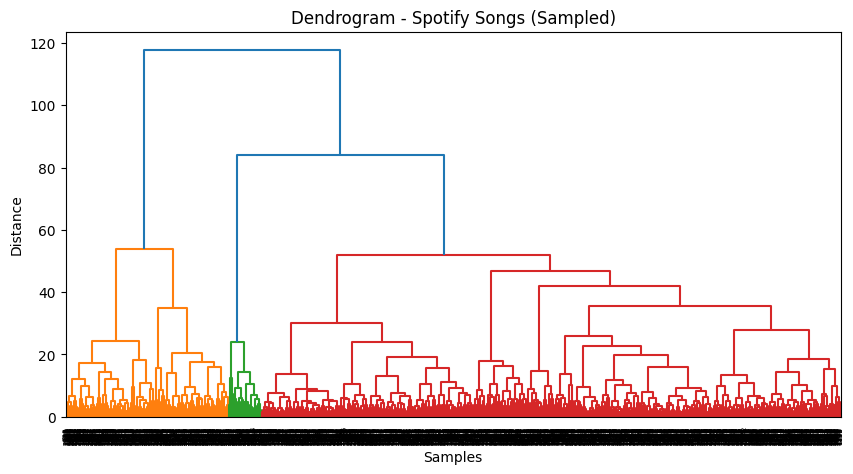

In [17]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram - Spotify Songs (Sampled)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [18]:
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels = hc.fit_predict(X_scaled)

X_sample['Cluster'] = labels

In [19]:
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.24605491043152564


In [20]:
cluster_summary = X_sample.groupby('Cluster').mean()
print(cluster_summary)

         acousticness  danceability    duration_ms    energy  \
Cluster                                                        
0            0.201893      0.609663  228488.240518  0.678250   
1            0.875174      0.285125  256282.235088  0.162297   
2            0.795198      0.553500  217550.984127  0.665222   
3            0.816569      0.437389  233979.341954  0.245655   

         instrumentalness  liveness   loudness  speechiness       tempo  \
Cluster                                                                   
0                0.081970  0.203944  -7.045206     0.099452  121.703303   
1                0.846078  0.140886 -21.297523     0.044974  105.065786   
2                0.000059  0.734094 -12.440071     0.893119   99.201651   
3                0.041990  0.179618 -15.024566     0.056306  111.077046   

          valence  
Cluster            
0        0.529751  
1        0.155095  
2        0.411855  
3        0.272286  


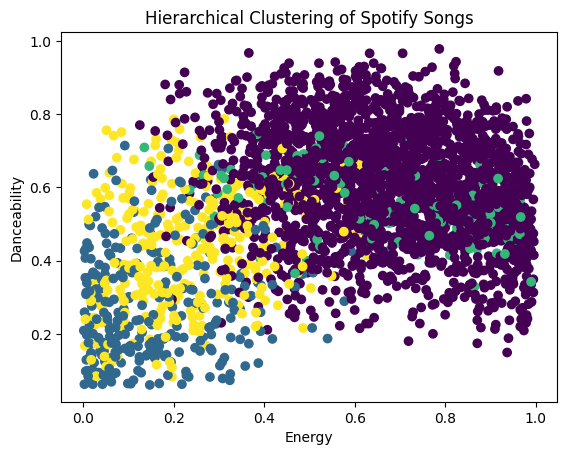

In [21]:
plt.figure()
plt.scatter(X_sample['energy'], 
            X_sample['danceability'], 
            c=X_sample['Cluster'])

plt.xlabel("Energy")
plt.ylabel("Danceability")
plt.title("Hierarchical Clustering of Spotify Songs")
plt.show()

In [ ]:
qq